In [3]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
file_path = "../../../results/2020/23/calorimeter_23_year_2020filtriranje.csv"

data = pd.read_csv(file_path, index_col=[0])
df = pd.DataFrame(data)  

=== Mode Distribution ===
mode
cooling    240046
neutral     89165
heating     73344
Name: count, dtype: int64

Total rows: 402555
Cooling: 240046 rows (59.63%)
Heating: 73344 rows (18.22%)
Neutral: 89165 rows (22.15%)

=== First 10 rows with mode column ===
                          timestamp  supply_temperature     mode  mode_change  \
id                                                                              
24055331 2020-01-01 00:00:05.511485                59.1  cooling         True   
24055360 2020-01-01 00:01:05.406786                59.1  cooling        False   
24055389 2020-01-01 00:02:05.986299                59.1  cooling        False   
24055418 2020-01-01 00:03:05.580119                58.8  cooling        False   
24055447 2020-01-01 00:04:06.303837                58.8  cooling        False   
24055476 2020-01-01 00:05:05.924556                58.6  cooling        False   
24055505 2020-01-01 00:06:05.457481                58.6  cooling        False   
24055534 202

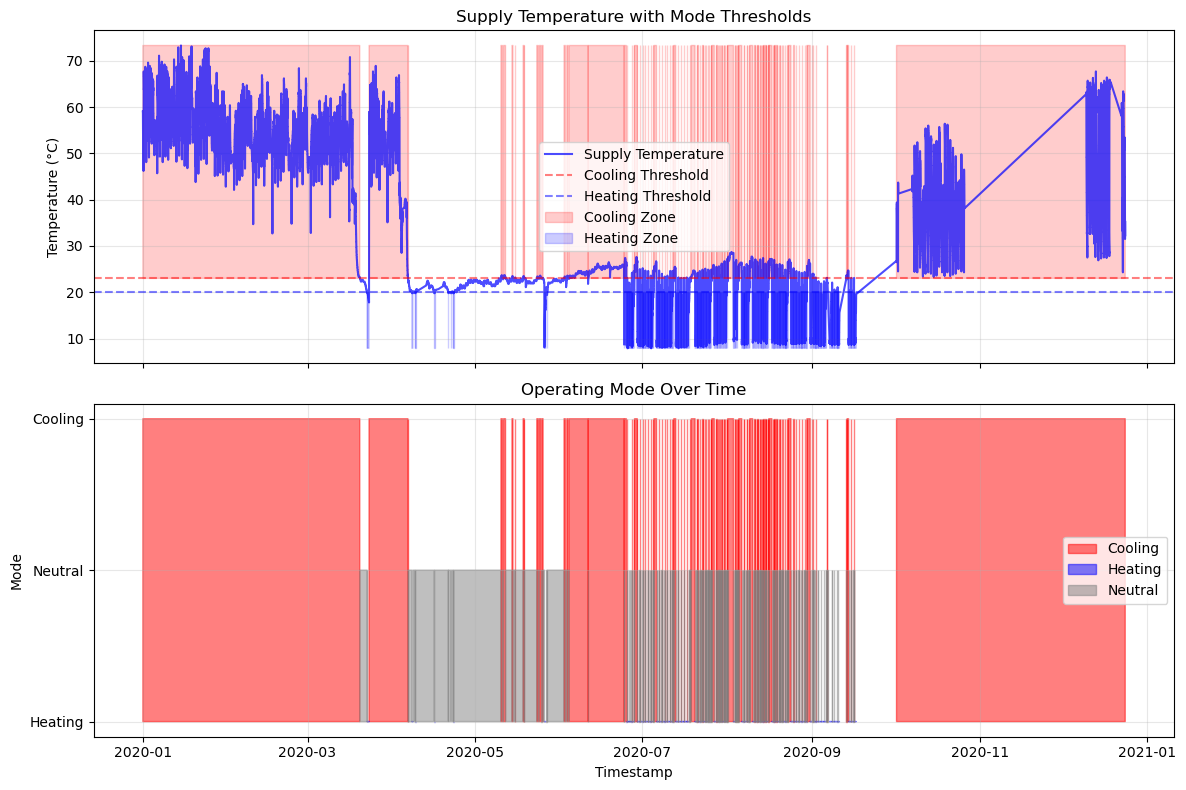

In [4]:
import pandas as pd

COOLING_THRESHOLD = 23  
HEATING_THRESHOLD = 20  

def assign_mode(temp):
    if temp > COOLING_THRESHOLD:
        return 'cooling'
    elif temp < HEATING_THRESHOLD:
        return 'heating'
    else:
        return 'neutral' 

df['timestamp'] = pd.to_datetime(df['timestamp'])
df['batch_timestamp'] = pd.to_datetime(df['batch_timestamp'])

df = df.sort_values('timestamp')

df['mode'] = df['supply_temperature'].apply(assign_mode)

df['mode_change'] = df['mode'] != df['mode'].shift(1)

df['interval_id'] = df['mode_change'].cumsum()

print("=== Mode Distribution ===")
mode_counts = df['mode'].value_counts()
print(mode_counts)
print(f"\nTotal rows: {len(df)}")

for mode in ['cooling', 'heating', 'neutral']:
    if mode in mode_counts.index:
        count = mode_counts[mode]
        percentage = (count / len(df)) * 100
        print(f"{mode.capitalize()}: {count} rows ({percentage:.2f}%)")

print("\n=== First 10 rows with mode column ===")
print(df[['timestamp', 'supply_temperature', 'mode', 'mode_change', 'interval_id']].head(10))

print("\n=== Sample rows for each mode ===")
for mode in ['cooling', 'heating', 'neutral']:
    if mode in df['mode'].unique():
        mode_sample = df[df['mode'] == mode].head(3)
        print(f"\n{mode.capitalize()} mode sample:")
        print(mode_sample[['timestamp', 'supply_temperature', 'mode']])

df_cooling = df[df['mode'] == 'cooling'].copy()
df_heating = df[df['mode'] == 'heating'].copy()
df_neutral = df[df['mode'] == 'neutral'].copy()

print(f"\n=== Separate DataFrames ===")
print(f"Cooling DataFrame: {len(df_cooling)} rows")
print(f"Heating DataFrame: {len(df_heating)} rows")
print(f"Neutral DataFrame: {len(df_neutral)} rows")

print("\n=== Temperature Statistics by Mode ===")
for mode, mode_df in [('cooling', df_cooling), ('heating', df_heating), ('neutral', df_neutral)]:
    if len(mode_df) > 0:
        print(f"\n{mode.capitalize()} mode:")
        print(f"  Temperature range: {mode_df['supply_temperature'].min():.2f}°C to {mode_df['supply_temperature'].max():.2f}°C")
        print(f"  Average temperature: {mode_df['supply_temperature'].mean():.2f}°C")
        print(f"  Time span: {mode_df['timestamp'].min()} to {mode_df['timestamp'].max()}")

import matplotlib.pyplot as plt

+fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(df['timestamp'], df['supply_temperature'], 'b-', alpha=0.7, label='Supply Temperature')
ax1.axhline(y=COOLING_THRESHOLD, color='r', linestyle='--', alpha=0.5, label='Cooling Threshold')
ax1.axhline(y=HEATING_THRESHOLD, color='b', linestyle='--', alpha=0.5, label='Heating Threshold')
ax1.fill_between(df['timestamp'], COOLING_THRESHOLD, df['supply_temperature'].max(), 
                 where=(df['supply_temperature'] > COOLING_THRESHOLD), 
                 alpha=0.2, color='red', label='Cooling Zone')
ax1.fill_between(df['timestamp'], df['supply_temperature'].min(), HEATING_THRESHOLD, 
                 where=(df['supply_temperature'] < HEATING_THRESHOLD), 
                 alpha=0.2, color='blue', label='Heating Zone')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Supply Temperature with Mode Thresholds')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

mode_numeric = df['mode'].map({'cooling': 2, 'neutral': 1, 'heating': 0})
ax2.fill_between(df['timestamp'], 0, mode_numeric, 
                 where=(df['mode'] == 'cooling'), 
                 alpha=0.5, color='red', label='Cooling')
ax2.fill_between(df['timestamp'], 0, mode_numeric, 
                 where=(df['mode'] == 'heating'), 
                 alpha=0.5, color='blue', label='Heating')
ax2.fill_between(df['timestamp'], 0, mode_numeric, 
                 where=(df['mode'] == 'neutral'), 
                 alpha=0.5, color='gray', label='Neutral')
ax2.set_ylabel('Mode')
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(['Heating', 'Neutral', 'Cooling'])
ax2.set_title('Operating Mode Over Time')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.xlabel('Timestamp')
plt.tight_layout()
plt.show()


In [5]:
df_cooling.to_csv('../../../results/2020/23/calorimeter_23_year_2020filtriranje_cooling.csv', index=False)
df_heating.to_csv('../../../results/2020/23/calorimeter_23_year_2020filtriranje_heating.csv', index=False)